In [6]:
library(pROC)
library(caret)
library(dplyr)
library(glmnet)
library(readr)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Warning message:
“package ‘caret’ was built under R version 4.3.3”
Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Loading required package: lattice


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix

Loaded glmnet 4.1-8



In [15]:
load("/vol/projects/yzhang/500FG_aging/output/05_methylation/methylation_pediction.Rdata")

In [7]:
Mvalue <- read.csv("/vol/projects/yzhang/500FG_aging/input/variance/cumulative_variance_input/Mvalue_pca_scores1.csv")
rownames(Mvalue) <- Mvalue[,1]
Mvalue <- Mvalue[,-1]
head(Mvalue)
dim(Mvalue)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,⋯,PC297,PC298,PC299,PC300,PC301,PC302,PC303,PC304,PC305,PC306
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV022,-89.55597,285.03943,-77.09504,149.89091,-103.652181,98.37127,-14.621765,18.050756,-13.891978,12.23636,⋯,-10.6689363,-2.2054073,5.52968261,-4.6525792,4.4234102,-2.699177,2.9563540,-5.0895289,0.50461263,-3.160206e-13
HV028,-455.62362,57.53416,-96.54271,57.17830,-179.081959,46.66997,-27.829585,-26.630039,16.404523,-36.73034,⋯,-0.5062860,-3.1048387,-1.44308118,0.6835594,0.3143374,1.181802,1.1580641,0.2177154,-0.36705523,-2.731981e-13
HV029,-34.89258,133.14327,-35.26221,14.39773,74.765070,-42.30982,-8.030741,-11.616598,-42.974678,51.56796,⋯,-7.8094273,-0.9857189,3.38413985,1.0494126,-4.1727374,-3.900855,-2.9331491,-0.8097501,-8.82212406,-4.184144e-13
HV030,-1067.27335,350.58511,-207.65137,-69.93145,7.370033,-414.93734,374.052684,1291.456309,232.635951,179.60214,⋯,-0.6165777,0.5723471,-0.07995151,0.7273291,1.1869384,0.621924,-0.3669948,0.3985080,0.86912073,-3.692602e-13
HV031,-204.35868,-41.95885,-38.96657,-35.25796,169.415125,-59.06726,-14.596503,-8.776596,-32.560130,-10.21064,⋯,-4.4949851,-4.7043013,2.41882508,2.0874823,-4.0260954,1.889594,4.2062668,-0.1493890,4.85318889,-6.831567e-13
HV032,-718.07771,30.62770,-142.50584,120.92777,-164.540713,134.97652,12.851544,39.482103,6.279376,-407.04825,⋯,-0.7657846,-1.2552778,-0.32334237,2.4143329,-0.2086839,3.357782,4.2817537,1.8637663,-0.05416694,-5.973264e-13


[1] 306 306

In [8]:
basicPhenos = read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/Age_group_basicPhenos.csv")
head(basicPhenos)
# prepare cytokine_filter and EAA_filter_match
idx = intersect(rownames(Mvalue), basicPhenos$ID_500fg) 
length(idx) #458samples
Mvalue_filter = Mvalue[which(rownames(Mvalue) %in% idx),]
head(Mvalue_filter)  #458samples,1596 metabolite
dim(Mvalue_filter)

basicPhenos_filter = basicPhenos %>% filter(ID_500fg %in% idx)
head(basicPhenos_filter) #458samples
dim(basicPhenos_filter)

sum(rownames(Mvalue_filter) == basicPhenos_filter$ID_500fg)

basicPhenos_filter_match = basicPhenos_filter[match(rownames(Mvalue_filter), basicPhenos_filter$ID_500fg), ]

sum(basicPhenos_filter_match$ID_500fg == rownames(Mvalue_filter))
head(basicPhenos_filter_match) 
dim(basicPhenos_filter_match) #458samples

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,2,HV043,male,18,182,50,15.09480,Married,University student,European,Rarely,Yes,Yes,16,12,346,2013,Group 1
2,16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
3,41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
4,51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
5,56,HV497,female,18,157,49,19.87910,Married,Hogeschool opleiding (HBO),Asian,Rarely,No,No,24,11,324,2014,Group 1
6,148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1


[1] 305

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,⋯,PC297,PC298,PC299,PC300,PC301,PC302,PC303,PC304,PC305,PC306
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV022,-89.55597,285.03943,-77.09504,149.89091,-103.652181,98.37127,-14.621765,18.050756,-13.891978,12.23636,⋯,-10.6689363,-2.2054073,5.52968261,-4.6525792,4.4234102,-2.699177,2.9563540,-5.0895289,0.50461263,-3.160206e-13
HV028,-455.62362,57.53416,-96.54271,57.17830,-179.081959,46.66997,-27.829585,-26.630039,16.404523,-36.73034,⋯,-0.5062860,-3.1048387,-1.44308118,0.6835594,0.3143374,1.181802,1.1580641,0.2177154,-0.36705523,-2.731981e-13
HV029,-34.89258,133.14327,-35.26221,14.39773,74.765070,-42.30982,-8.030741,-11.616598,-42.974678,51.56796,⋯,-7.8094273,-0.9857189,3.38413985,1.0494126,-4.1727374,-3.900855,-2.9331491,-0.8097501,-8.82212406,-4.184144e-13
HV030,-1067.27335,350.58511,-207.65137,-69.93145,7.370033,-414.93734,374.052684,1291.456309,232.635951,179.60214,⋯,-0.6165777,0.5723471,-0.07995151,0.7273291,1.1869384,0.621924,-0.3669948,0.3985080,0.86912073,-3.692602e-13
HV031,-204.35868,-41.95885,-38.96657,-35.25796,169.415125,-59.06726,-14.596503,-8.776596,-32.560130,-10.21064,⋯,-4.4949851,-4.7043013,2.41882508,2.0874823,-4.0260954,1.889594,4.2062668,-0.1493890,4.85318889,-6.831567e-13
HV032,-718.07771,30.62770,-142.50584,120.92777,-164.540713,134.97652,12.851544,39.482103,6.279376,-407.04825,⋯,-0.7657846,-1.2552778,-0.32334237,2.4143329,-0.2086839,3.357782,4.2817537,1.8637663,-0.05416694,-5.973264e-13


[1] 305 306

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
2,41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
3,51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
4,56,HV497,female,18,157,49,19.87910,Married,Hogeschool opleiding (HBO),Asian,Rarely,No,No,24,11,324,2014,Group 1
5,148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1
6,151,HV461,male,18,183,73,21.79820,Married,University student,European,Rarely,Yes,Yes,20,10,290,2014,Group 1


[1] 305  18

[1] 2

[1] 305

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
59,196,HV022,female,20,152,45,19.47715,Cohabitation,Middelbaar beroepsonderwijs (MBO),European,Rarely,No,No,3,10,273,2013,Group 2
245,203,HV028,female,29,170,62,21.45329,Single living alone,Middelbaar beroepsonderwijs (MBO),European,Once a month,No,No,30,9,270,2013,Group 5
178,180,HV029,male,24,188,97,27.44455,Married,Hogeschool opleiding (HBO),European,Daily,Yes,No,7,10,277,2013,Group 4
201,197,HV030,female,25,161,57,21.98989,Single living alone,Hogeschool opleiding (HBO),European,Never,No,No,3,10,273,2013,Group 4
89,181,HV031,female,21,180,66,20.37037,Married,University student,European,Once a month,Yes,No,7,10,277,2013,Group 2
219,182,HV032,male,26,180,78,24.07407,Married,Hogeschool opleiding (HBO),European,Daily,Yes,Yes,7,10,277,2013,Group 4


[1] 305  18

In [9]:
Mvalue_age <- cbind(Mvalue_filter, Age = basicPhenos_filter_match$Age)
head(Mvalue_age)
dim(Mvalue_age)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,⋯,PC298,PC299,PC300,PC301,PC302,PC303,PC304,PC305,PC306,Age
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
HV022,-89.55597,285.03943,-77.09504,149.89091,-103.652181,98.37127,-14.621765,18.050756,-13.891978,12.23636,⋯,-2.2054073,5.52968261,-4.6525792,4.4234102,-2.699177,2.9563540,-5.0895289,0.50461263,-3.160206e-13,20
HV028,-455.62362,57.53416,-96.54271,57.17830,-179.081959,46.66997,-27.829585,-26.630039,16.404523,-36.73034,⋯,-3.1048387,-1.44308118,0.6835594,0.3143374,1.181802,1.1580641,0.2177154,-0.36705523,-2.731981e-13,29
HV029,-34.89258,133.14327,-35.26221,14.39773,74.765070,-42.30982,-8.030741,-11.616598,-42.974678,51.56796,⋯,-0.9857189,3.38413985,1.0494126,-4.1727374,-3.900855,-2.9331491,-0.8097501,-8.82212406,-4.184144e-13,24
HV030,-1067.27335,350.58511,-207.65137,-69.93145,7.370033,-414.93734,374.052684,1291.456309,232.635951,179.60214,⋯,0.5723471,-0.07995151,0.7273291,1.1869384,0.621924,-0.3669948,0.3985080,0.86912073,-3.692602e-13,25
HV031,-204.35868,-41.95885,-38.96657,-35.25796,169.415125,-59.06726,-14.596503,-8.776596,-32.560130,-10.21064,⋯,-4.7043013,2.41882508,2.0874823,-4.0260954,1.889594,4.2062668,-0.1493890,4.85318889,-6.831567e-13,21
HV032,-718.07771,30.62770,-142.50584,120.92777,-164.540713,134.97652,12.851544,39.482103,6.279376,-407.04825,⋯,-1.2552778,-0.32334237,2.4143329,-0.2086839,3.357782,4.2817537,1.8637663,-0.05416694,-5.973264e-13,26


[1] 305 307

In [5]:
#Age
#split data to trianing and testing set
set.seed(1)
splitSample <- createDataPartition(Mvalue_age$Age, p = 0.7, list = FALSE)
training <- Mvalue_age[splitSample,]
validation <- Mvalue_age[-splitSample,]

#settings grid tuning and cv
netGrid <- expand.grid(.alpha=1,.lambda=seq(0,1,by=0.01))  
netctrl <- trainControl(method="repeatedcv", number=10, repeats=5) 

#training
netFit <- train(Age~.,data = training, method = 'glmnet', metric = "RMSE",tuneGrid=netGrid,trControl = netctrl,preProcess = "scale")

#look at the model
head(arrange(netFit$results, RMSE) )

netFit$bestTune

my.glmnet.model<- netFit$finalModel
aa<- as.matrix(coef(my.glmnet.model,s=netFit$bestTune$lambda))
b<-as.data.frame(aa[which(aa[,1]!=0),])
colnames(b)<-"coef"
b

,alpha,lambda,RMSE,Rsquared,MAE,RMSESD,RsquaredSD,MAESD
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,0.63,7.982688,0.7164531,5.022059,4.045980,0.1664956,1.325649
2,1,0.64,7.983251,0.7166866,5.026898,4.024582,0.1658620,1.324876
3,1,0.62,7.983646,0.7160775,5.019674,4.066761,0.1670902,1.325863
4,1,0.65,7.984443,0.7168436,5.032411,4.002697,0.1652093,1.323459
5,1,0.61,7.985587,0.7156346,5.017517,4.086744,0.1676937,1.326366
6,1,0.66,7.986939,0.7169202,5.038256,3.980389,0.1645777,1.321812


,alpha,lambda
,<dbl>,<dbl>
64,1,0.63


,coef
,<dbl>
(Intercept),27.7077798714
PC2,0.8009214131
PC3,-0.5630186480
PC4,4.3826952168
PC5,6.0299389630
PC6,-1.0347327129
PC7,-0.7390092671
PC10,-1.0545187388
PC12,-0.3758843399


In [6]:
#Prediction on validation set
predictions <- predict(netFit, validation)

cor.test(predictions,validation$Age)

RMSE(predictions,validation$Age)


	Pearson's product-moment correlation

data:  predictions and validation$Age
t = 20.952, df = 88, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.8700583 0.9417816
sample estimates:
      cor 
0.9126982 


[1] 6.971131

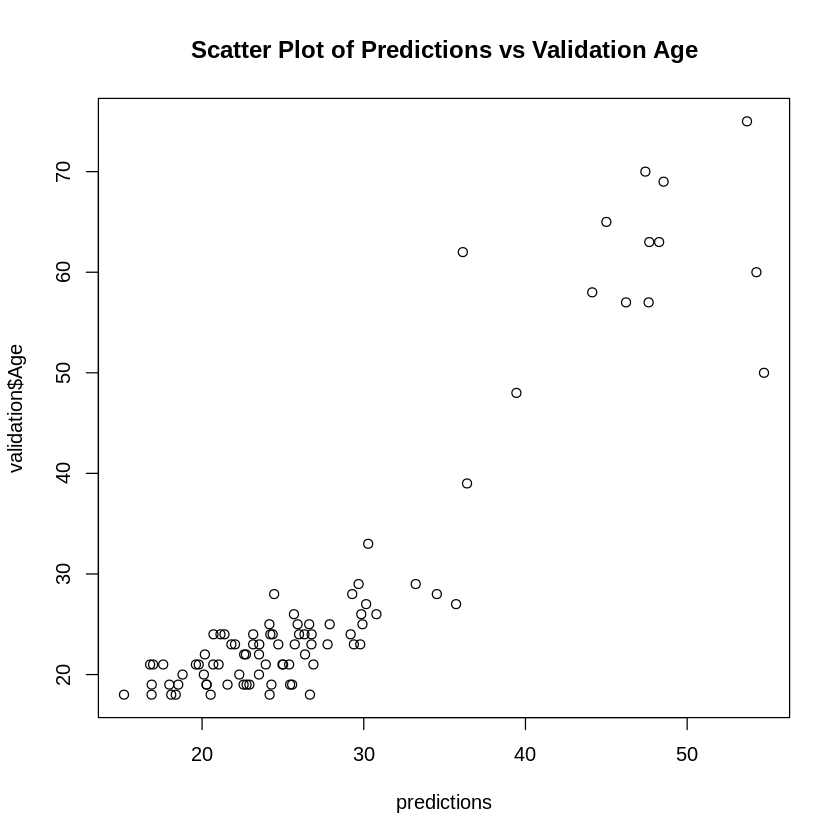

In [7]:
plot(predictions, validation$Age,
     xlab = "predictions", 
     ylab = "validation$Age",
     main = "Scatter Plot of Predictions vs Validation Age",
     pch = 1)  # pch = 1 present circle

In [10]:
##perform 100 times
# Custom function to train and evaluate the model
train_and_evaluate <- function(data, seed) {
  set.seed(seed)
  
  # Split data into training and validation sets
  splitSample <- createDataPartition(data$Age, p = 0.7, list = FALSE)
  training <- data[splitSample, ]
  validation <- data[-splitSample, ]
  
  # Set up the grid for hyperparameter tuning
  netGrid <- expand.grid(.alpha = 1, .lambda = seq(0, 1, by = 0.01))  
  netctrl <- trainControl(method = "repeatedcv", number = 10, repeats = 5) 
  
  # Train the model
  netFit <- train(Age ~ ., data = training, method = "glmnet", metric = "RMSE",
                  tuneGrid = netGrid, trControl = netctrl, preProcess = "scale")
  
  # Make predictions on training and validation sets
  train_predictions <- predict(netFit, newdata = training)
  val_predictions <- predict(netFit, newdata = validation)
  
  # Compute performance metrics for training set
  train_rmse <- sqrt(mean((training$Age - train_predictions)^2))  # RMSE
  train_mse <- mean((training$Age - train_predictions)^2)         # MSE
  train_r_squared <- cor(training$Age, train_predictions)^2       # R²
  
  # Compute performance metrics for validation set
  val_rmse <- sqrt(mean((validation$Age - val_predictions)^2))    # RMSE
  val_mse <- mean((validation$Age - val_predictions)^2)           # MSE
  val_r_squared <- cor(validation$Age, val_predictions)^2         # R²
  
  # Return metrics
  list(
    train_RMSE = train_rmse,
    train_MSE = train_mse,
    train_R2 = train_r_squared,
    val_RMSE = val_rmse,
    val_MSE = val_mse,
    val_R2 = val_r_squared,
    best_model = netFit
  )
}

In [11]:
# Run the training process 100 times
set.seed(1)
results <- lapply(1:100, function(i) train_and_evaluate(Mvalue_age, seed = i))

# Extract metrics for training and validation sets
train_rmse_values <- sapply(results, function(x) x$train_RMSE)
train_mse_values <- sapply(results, function(x) x$train_MSE)
train_r2_values <- sapply(results, function(x) x$train_R2)

val_rmse_values <- sapply(results, function(x) x$val_RMSE)
val_mse_values <- sapply(results, function(x) x$val_MSE)
val_r2_values <- sapply(results, function(x) x$val_R2)

# Calculate mean and standard deviation for each metric
metrics_summary <- data.frame(
  Metric = c("Train RMSE", "Validation RMSE", 
             "Train MSE", "Validation MSE", 
             "Train R²", "Validation R²"),
  Mean = c(mean(train_rmse_values), mean(val_rmse_values),
           mean(train_mse_values), mean(val_mse_values),
           mean(train_r2_values), mean(val_r2_values)),
  SD = c(sd(train_rmse_values), sd(val_rmse_values),
         sd(train_mse_values), sd(val_mse_values),
         sd(train_r2_values), sd(val_r2_values))
)

# Print summary
head(metrics_summary)

,Metric,Mean,SD
,<chr>,<dbl>,<dbl>
1,Train RMSE,4.5620754,1.28567269
2,Validation RMSE,8.0923286,1.74545841
3,Train MSE,22.4489571,11.78919854
4,Validation MSE,68.5019411,30.92937426
5,Train R²,0.8947247,0.05491573
6,Validation R²,0.6938245,0.08199212


In [12]:
saveRDS(results, "/vol/projects/yzhang/500FG_aging/output/12_prediction/methylation_prediction_results_pca.rds")

png 
  2

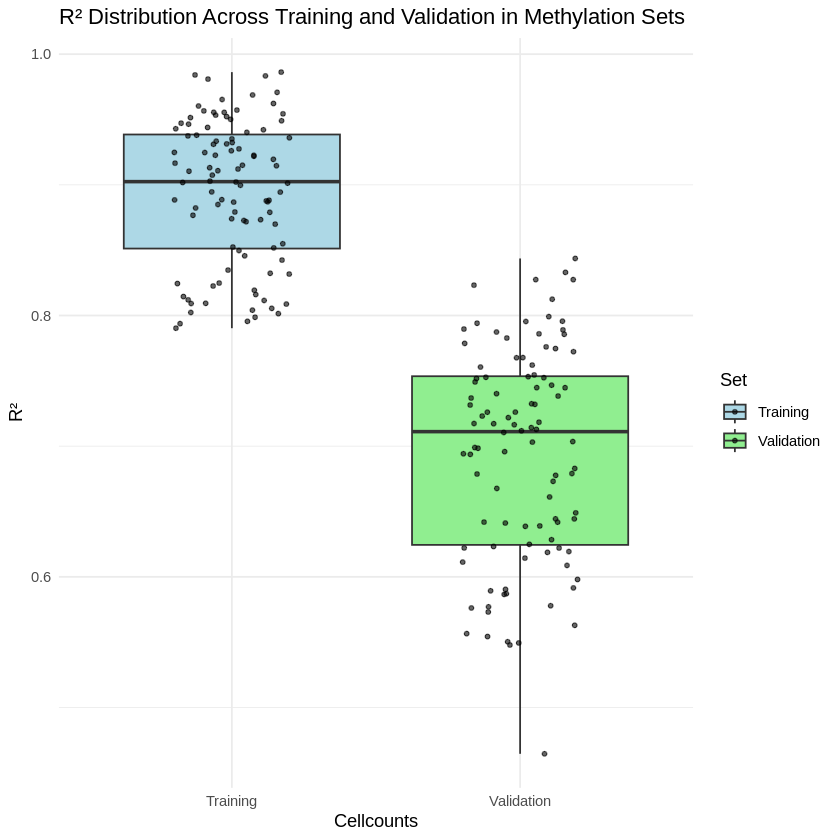

In [10]:
# Combine R² metrics into a single data frame for plotting
plot_data_r2 <- data.frame(
  Set = rep(c("Training", "Validation"), each = 100),
  R2 = c(train_r2_values, val_r2_values)
)

# Plot only R²
ppi <- 300
png("/vol/projects/yzhang/500FG_aging/output/05_methylation/methylation_cross_validation.png", 
    width = 5 * ppi, height = 4 * ppi, res = ppi)

g<-ggplot(plot_data_r2, aes(x = Set, y = R2, fill = Set)) +
  geom_boxplot(outlier.shape = NA) +  # Boxplot without outliers
  geom_jitter(position = position_jitterdodge(), size = 1, alpha = 0.6, color = "black") +  # Scatter points
  labs(title = "R² Distribution Across Training and Validation in Methylation Sets",
       x = "Cellcounts",
       y = "R²") +
  theme_minimal() +
  scale_fill_manual(values = c("lightblue", "lightgreen")) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5))

print(g)
dev.off()
print(g)

In [ ]:
####use the original data(too huge to open)
results <- readRDS("/vol/projects/yzhang/500FG_aging/output/12_prediction/methylation_prediction_results.rds")   
# Combine R² metrics into a single data frame for plotting
plot_data_r2 <- data.frame(
  Set = rep(c("Training", "Validation"), each = 100),
  R2 = c(train_r2_values, val_r2_values)
)

# Plot only R²
ppi <- 300
png("/vol/projects/yzhang/500FG_aging/output/05_methylation/methylation_cross_validation(raw).png", 
    width = 5 * ppi, height = 4 * ppi, res = ppi)

g<-ggplot(plot_data_r2, aes(x = Set, y = R2, fill = Set)) +
  geom_boxplot(outlier.shape = NA) +  # Boxplot without outliers
  geom_jitter(position = position_jitterdodge(), size = 1, alpha = 0.6, color = "black") +  # Scatter points
  labs(title = "R² Distribution Across Training and Validation in Methylation Sets",
       x = "Cellcounts",
       y = "R²") +
  theme_minimal() +
  scale_fill_manual(values = c("lightblue", "lightgreen")) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5))

print(g)
dev.off()
print(g)

In [13]:
save.image("/vol/projects/yzhang/500FG_aging/output/05_methylation/methylation_pediction.Rdata")